In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagXGB.backtest_class import BacktestLL
from Strategies.LeadLagXGB.strategy_class import StrategyLL, VolumeClass
tol=(1e-1)/2

from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, DatetimeTickFormatter, HoverTool
from bokeh.layouts import column
from bokeh.io import curdoc

from Strategies.BA_convergence.backtest_class import BacktestLL
from Strategies.BA_convergence.strategy_class import StrategyLL, VolumeClass

In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import warnings
warnings.filterwarnings('ignore')

In [53]:
#0.03	0.020	0.05	0.12	0.025	-0.050	1.5	100.0

In [54]:
ba_conv_large_threshold=0.03
ba_conv_small_threshold=0.02
ba_conv_volatility_threshold=0.05
ba_conv_ba_threshold=0.12

burnout_period=60
stop_profit = 0.3
makeagg_ratio = 0.6
trail_stop=100

take_profit=2
stop_loss=-1

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

MACD_long_threshold = 0.025
MACD_short_threshold = -0.05

minimum_intensity=1.5

# OOT part - Sep, Oct

In [55]:
data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_sep_oct_our_db.csv',
                    parse_dates=['datetime']).reset_index()

In [56]:
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

# Identify rows where bid_price and ask_price are the same as the previous row
same_prices = (data_lag["bid_price"] == data_lag["bid_price"].shift()) & (data_lag["ask_price"] == data_lag["ask_price"].shift())

# Identify rows where neither the current nor the previous row has a trade price
no_trade = data_lag["trd_price"].isna() & data_lag["trd_price"].shift().isna()

# Remove rows where both conditions hold (consecutive bid/ask prices & no trades)
data_lag = data_lag[~(same_prices & no_trade)]

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
0,0,2024-09-02 09:00:00.032,NaN,NaN,97.12,97.47,97.295,NaN,0.000
1,1,2024-09-02 09:00:01.469,NaN,NaN,97.13,97.47,97.300,NaN,1.437
2,2,2024-09-02 09:00:01.740,NaN,NaN,97.12,97.47,97.295,NaN,0.271
3,3,2024-09-02 09:00:02.371,NaN,NaN,97.13,97.47,97.300,NaN,0.631
4,4,2024-09-02 09:00:02.827,NaN,NaN,97.14,97.47,97.305,NaN,0.456


In [57]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee


param_dict['ba_conv_large_threshold']=ba_conv_large_threshold
param_dict['ba_conv_small_threshold']=ba_conv_small_threshold
param_dict['ba_conv_volatility_threshold']=ba_conv_volatility_threshold
param_dict['ba_conv_ba_threshold']=ba_conv_ba_threshold

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

In [58]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # As

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})


# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

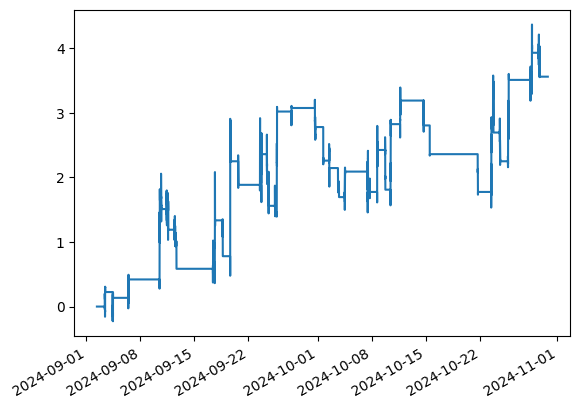

In [59]:
xx.plot()

In [60]:
xx[-1]

3.5600000000000165

# OOT part - Nov, Dec

In [61]:
data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_nov_dec_our_db.csv',
                    parse_dates=['datetime']).reset_index()

In [62]:
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

# Identify rows where bid_price and ask_price are the same as the previous row
same_prices = (data_lag["bid_price"] == data_lag["bid_price"].shift()) & (data_lag["ask_price"] == data_lag["ask_price"].shift())

# Identify rows where neither the current nor the previous row has a trade price
no_trade = data_lag["trd_price"].isna() & data_lag["trd_price"].shift().isna()

# Remove rows where both conditions hold (consecutive bid/ask prices & no trades)
data_lag = data_lag[~(same_prices & no_trade)]

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
0,0,2024-11-01 09:00:07.252,NaN,NaN,92.60,92.80,92.700,NaN,0.000
1,1,2024-11-01 09:00:14.258,NaN,NaN,92.61,92.80,92.705,NaN,7.006
2,2,2024-11-01 09:00:24.544,NaN,NaN,92.63,92.80,92.715,NaN,10.286
3,3,2024-11-01 09:00:40.392,NaN,NaN,92.63,92.76,92.695,NaN,15.848
4,4,2024-11-01 09:00:56.209,NaN,NaN,92.63,92.84,92.735,NaN,15.817


In [63]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee


param_dict['ba_conv_large_threshold']=ba_conv_large_threshold
param_dict['ba_conv_small_threshold']=ba_conv_small_threshold
param_dict['ba_conv_volatility_threshold']=ba_conv_volatility_threshold
param_dict['ba_conv_ba_threshold']=ba_conv_ba_threshold

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

In [64]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # As

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})


# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

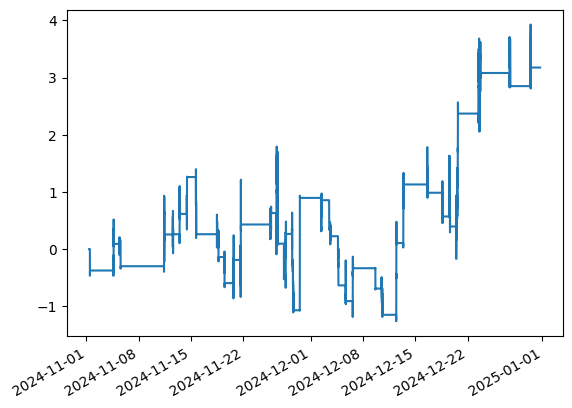

In [65]:
xx.plot()

In [66]:
xx[-1]

3.174999999999926

# OOT part - Jan, Feb

In [67]:
data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_jan_feb_our_db.csv',
                    parse_dates=['datetime']).reset_index()

In [68]:
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

# Identify rows where bid_price and ask_price are the same as the previous row
same_prices = (data_lag["bid_price"] == data_lag["bid_price"].shift()) & (data_lag["ask_price"] == data_lag["ask_price"].shift())

# Identify rows where neither the current nor the previous row has a trade price
no_trade = data_lag["trd_price"].isna() & data_lag["trd_price"].shift().isna()

# Remove rows where both conditions hold (consecutive bid/ask prices & no trades)
data_lag = data_lag[~(same_prices & no_trade)]

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
684,684,2025-01-02 09:00:36.629,NaN,NaN,82.00,82.33,82.165,NaN,55.985
685,685,2025-01-02 09:00:45.083,NaN,NaN,82.00,82.10,82.050,NaN,8.454
686,686,2025-01-02 09:00:55.214,NaN,NaN,82.00,82.00,82.000,NaN,10.131
687,687,2025-01-02 09:00:55.470,NaN,NaN,81.93,82.00,81.965,NaN,0.256
688,688,2025-01-02 09:00:55.610,NaN,NaN,81.93,82.10,82.015,NaN,0.140


In [69]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee


param_dict['ba_conv_large_threshold']=ba_conv_large_threshold
param_dict['ba_conv_small_threshold']=ba_conv_small_threshold
param_dict['ba_conv_volatility_threshold']=ba_conv_volatility_threshold
param_dict['ba_conv_ba_threshold']=ba_conv_ba_threshold

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

In [70]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # As

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})


# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

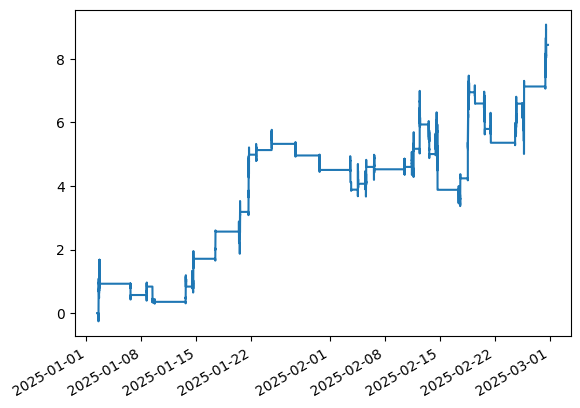

In [71]:
xx.plot()

In [72]:
xx[-1]

8.440000000000026

# All periods

## Data preparation

In [73]:
data_lag=pd.concat([pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_sep_oct_our_db.csv',
                    parse_dates=['datetime']).reset_index(), 
                   pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_nov_dec_our_db.csv',
                    parse_dates=['datetime']).reset_index(),
                   pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_jan_feb_our_db.csv',
                    parse_dates=['datetime']).reset_index()
                   ])

In [74]:
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [75]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [76]:
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [ ]:
# Identify rows where bid_price and ask_price are the same as the previous row
same_prices = (data_lag["bid_price"] == data_lag["bid_price"].shift()) & (data_lag["ask_price"] == data_lag["ask_price"].shift())

# Identify rows where neither the current nor the previous row has a trade price
no_trade = data_lag["trd_price"].isna() & data_lag["trd_price"].shift().isna()

# Remove rows where both conditions hold (consecutive bid/ask prices & no trades)
data_lag = data_lag[~(same_prices & no_trade)]

In [77]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
0,0,2024-09-02 09:00:00.032,NaN,NaN,97.12,97.47,97.295,NaN,0.000
1,1,2024-09-02 09:00:01.469,NaN,NaN,97.13,97.47,97.300,NaN,1.437
2,2,2024-09-02 09:00:01.740,NaN,NaN,97.12,97.47,97.295,NaN,0.271
3,3,2024-09-02 09:00:02.371,NaN,NaN,97.13,97.47,97.300,NaN,0.631
4,4,2024-09-02 09:00:02.827,NaN,NaN,97.14,97.47,97.305,NaN,0.456


## Parameters and calculations

In [78]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee


param_dict['ba_conv_large_threshold']=ba_conv_large_threshold
param_dict['ba_conv_small_threshold']=ba_conv_small_threshold
param_dict['ba_conv_volatility_threshold']=ba_conv_volatility_threshold
param_dict['ba_conv_ba_threshold']=ba_conv_ba_threshold

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold

param_dict['minimum_intensity'] = minimum_intensity

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop



vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

In [79]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# As

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lag = ColumnDataSource(data_lag)

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# Plotting with hover tools
lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})


hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lag Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

# Add hover tools to the plot
p.add_tools(hover_position, hover_lag)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

## Results

In [80]:
# Convert 'timestamp' to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

<Axes: >

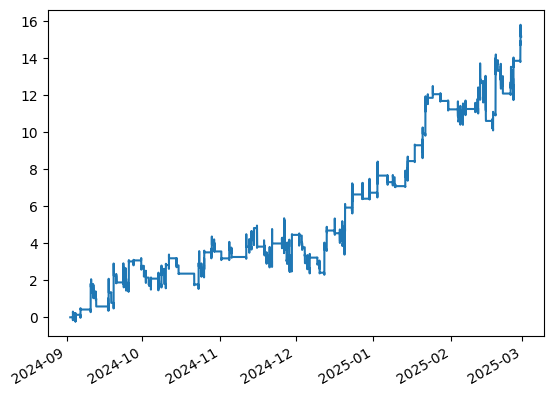

In [81]:
xx.plot()

In [82]:
#df[0:50]

In [83]:
xx[-1:]

2025-02-28 17:59:59.095    15.175
dtype: float64

In [84]:
df['date']=df['timestamp'].apply(lambda x: x.date())

In [85]:
# # Ensure that the index is a DatetimeIndex if not already
# xx.index = pd.to_datetime(xx.index)

# # Filter for dates in 2024
# dates_2024 = xx[xx.index.year == 2024].index.normalize().unique()

# # Iterate over each unique date in 2024 and plot
# for date in dates_2024:
#     daily_data = xx[(xx.index >= date) & (xx.index < date + pd.Timedelta(days=1))]
#     daily_data = daily_data-daily_data[0]
    
#     # Plot the data for the current date
#     plt.figure(figsize=(10, 6))
#     daily_data.plot()
#     plt.title(f"Data for {date.date()}")
#     plt.xlabel("Time")
#     plt.ylabel("Values")
#     plt.grid(True)
#     plt.show()

In [86]:
df['revenue']=-1*df['position']*df['price_level']

In [87]:
a=df.groupby('date')['revenue'].sum()

In [88]:
sum(a)

26.584999999998857

In [89]:
(a>0).value_counts()

revenue
True     53
False    42
Name: count, dtype: int64

In [90]:
len(df)

326

In [91]:
sum(a)/len(df)

0.08154907975459771

In [92]:
# Select odd and even indexed rows
even_index = df.iloc[1::2]['revenue'].reset_index(drop=True)  # Rows 1, 3, 5, ...
odd_index = df.iloc[0::2]['revenue'].reset_index(drop=True)   # Rows 0, 2, 4, ...

# Subtract odd-indexed rows from even-indexed rows
difference = even_index + odd_index
reutrn_df=pd.DataFrame(difference)
reutrn_df.columns=['returns']
reutrn_df

,returns
0,0.295
1,-0.295
2,0.345
3,0.355
4,1.295
...,...
158,-0.265
159,-0.305
160,1.745
161,1.145


Accuracy: 0.5214723926380368


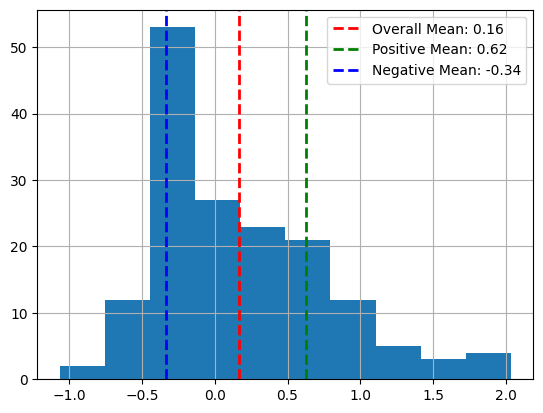

In [93]:
# Assuming 'reutrn_df' is a DataFrame and 'returns' is a column in it
overall_mean = reutrn_df['returns'].mean()
positive_mean = reutrn_df[reutrn_df['returns'] > 0]['returns'].mean()
negative_mean = reutrn_df[reutrn_df['returns'] < 0]['returns'].mean()
 
# Print accuracy
accuracy = sum(reutrn_df['returns'] > 0) / len(reutrn_df)
print('Accuracy:', accuracy)
 
# Plot histogram
reutrn_df[abs(reutrn_df['returns']) >= 0.01]['returns'].hist()
 
# Add vertical lines
plt.axvline(overall_mean, color='r', linestyle='dashed', linewidth=2, label=f'Overall Mean: {overall_mean:.2f}')
plt.axvline(positive_mean, color='g', linestyle='dashed', linewidth=2, label=f'Positive Mean: {positive_mean:.2f}')
plt.axvline(negative_mean, color='b', linestyle='dashed', linewidth=2, label=f'Negative Mean: {negative_mean:.2f}')
 
# Add a legend
plt.legend()
 
# Show plot
plt.show()

In [94]:

# Initialize variables
counts = []
current_value = None
current_count = 0

# Loop through the data
for value in pd.DataFrame(a>0)['revenue'].apply(int):
    if value == current_value:
        current_count += 1
    else:
        if current_value is not None:
            counts.append((current_value, current_count))
        current_value = value
        current_count = 1

# Append the last sequence
counts.append((current_value, current_count))

# Display the result
counts_df = pd.DataFrame(counts, columns=['Value', 'Count'])

counts_df[counts_df['Value']==1].value_counts()

Value  Count
1      1        10
       2         8
       3         4
       4         2
       7         1
Name: count, dtype: int64

In [95]:
# Step 1: Calculate sign changes (+1 for positive, -1 for negative)
signs = reutrn_df['returns'].apply(lambda x: 1 if x > 0 else -1)

# Step 2: Identify streaks by checking where the sign changes
streaks = (signs != signs.shift()).cumsum()

# Step 3: Group by streak and calculate streak lengths
streak_lengths = signs.groupby(streaks).size().reset_index(name='length')
streak_lengths['sign'] = signs.groupby(streaks).first().values

# Step 4: Distribution of positive and negative streaks
streak_distribution = streak_lengths.groupby(['sign', 'length']).size().unstack(fill_value=0)

streak_distribution

length,1,2,3,4,5
sign,,,,,
-1,19,9,8,3,1
1,20,9,4,5,3


In [96]:
result=[]
for date in sorted(list(set(df['timestamp'].apply(lambda x: x.date())))):
    df_day = df[df['timestamp'].apply(lambda x: x.date()) == date]
    even_index = df_day.iloc[1::2]['revenue'].reset_index(drop=True)  # Rows 1, 3, 5, ...
    odd_index = df_day.iloc[0::2]['revenue'].reset_index(drop=True)   # Rows 0, 2, 4, ...
    
    # Calculate the difference
    difference = even_index + odd_index
    
    # Create the DataFrame
    return_df = pd.DataFrame(difference)
    return_df.columns = ['returns']
    
    # Identify the first occurrence of 'returns' < -1
    mask = return_df['returns'] < -1.2
    row_index = mask.idxmax()  # Get the index of the first occurrence
    
    # If a value < -1 is found, slice the DataFrame to remove all subsequent rows
    if mask.any():
        return_df = return_df.iloc[:row_index+1]
        
    #print(return_df)
    result.append(return_df)
    
    
sum(pd.concat(result)['returns'])

26.584999999998857

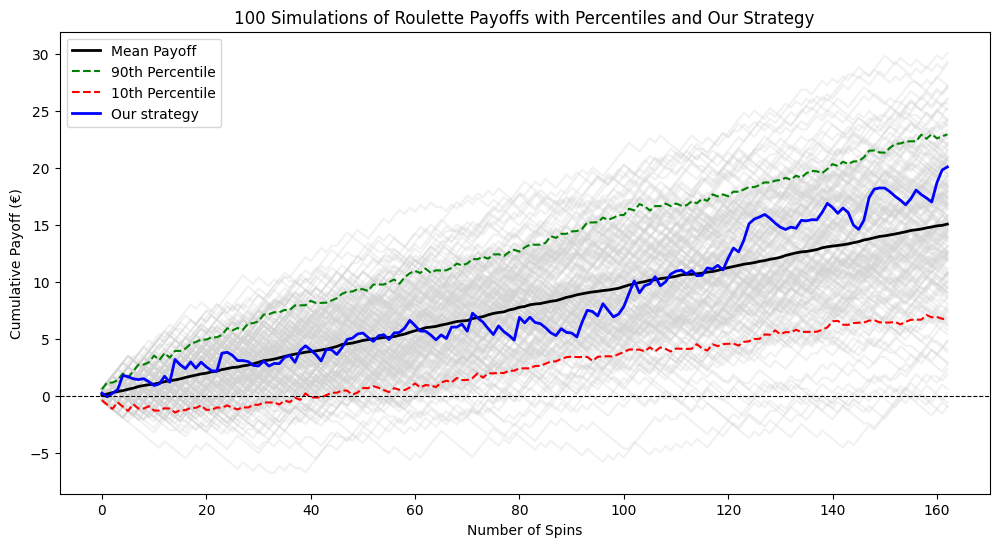

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_spins = int(len(df) / 2)  # Number of spins per simulation
num_simulations = 200  # Number of simulations
payoff_red = positive_mean - 0.04  # Payoff for red
payoff_black = negative_mean - 0.04  # Loss for black

# Roulette wheel setup
colors = ['red'] * 18 + ['black'] * 18 + ['green']

# Run simulations
all_simulations = []
np.random.seed(22)  # For reproducibility

for _ in range(num_simulations):
    results = np.random.choice(colors, num_spins)
    payoffs = [payoff_red if color == 'red' else payoff_black if color == 'black' else 0 for color in results]
    cumulative_payoffs = np.cumsum(payoffs)
    all_simulations.append(cumulative_payoffs)

# Convert to array for easier calculations
all_simulations = np.array(all_simulations)

# Calculate the mean, 75th percentile, and 25th percentile of cumulative payoffs
mean_payoff = all_simulations.mean(axis=0)
percentile_90 = np.percentile(all_simulations, 90, axis=0)
percentile_10 = np.percentile(all_simulations, 10, axis=0)

# Plot each simulation in one graph
plt.figure(figsize=(12, 6))
for i in range(num_simulations):
    plt.plot(all_simulations[i], color="lightgrey", alpha=0.3)

# Plot the mean of all simulations in black
plt.plot(mean_payoff, color="black", label="Mean Payoff", linewidth=2)

# Plot the 75th and 25th percentiles
plt.plot(percentile_90, color="green", linestyle="--", label="90th Percentile")
plt.plot(percentile_10, color="red", linestyle="--", label="10th Percentile")

# Plot the cumulative payoff of "Our strategy" if defined
plt.plot((reutrn_df['returns'] - 0.04).cumsum(), label="Our strategy", color="blue", linewidth=2)

# Plot formatting
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Zero line
plt.xlabel("Number of Spins")
plt.ylabel("Cumulative Payoff (€)")
plt.title("100 Simulations of Roulette Payoffs with Percentiles and Our Strategy")
plt.legend()
plt.show()

In [98]:
a=df.groupby('date')['revenue'].sum()
(a>0).value_counts()

revenue
True     53
False    42
Name: count, dtype: int64

In [99]:
# Select odd and even indexed rows
even_index = df.iloc[1::2]['revenue'].reset_index(drop=True)  # Rows 1, 3, 5, ...
odd_index = df.iloc[0::2]['revenue'].reset_index(drop=True)   # Rows 0, 2, 4, ...

# Subtract odd-indexed rows from even-indexed rows
difference = even_index + odd_index
reutrn_df=pd.DataFrame(difference)
reutrn_df.columns=['returns']
len(reutrn_df)

163